In [1]:
import warnings; warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from binance import Client

In [2]:
client = Client()
def get_tickers():
    tickers = []
    for info in client.futures_mark_price():
        ticker = info['symbol']
        if ticker[-4:] == "USDT":
            tickers.append(info['symbol'])
    return tickers

def get_sample(ticker, start_date="1 Jan, 2021"):
    klines = np.array(client.futures_historical_klines(ticker, Client.KLINE_INTERVAL_1DAY, start_date))
    sample = pd.DataFrame(klines.reshape(-1, 12), dtype=float, columns=['datetime',
                                                                        'open', 
                                                                        'high', 
                                                                        'low', 
                                                                        'close', 
                                                                        'volume', 
                                                                        'close time', 
                                                                        'quote asset volume, number of trades', 
                                                                        'number of trades',
                                                                        'taker buy base asset volume', 
                                                                        'taker buy quote asset volume', 
                                                                        'ignore'])
    sample['datetime'] = pd.to_datetime(sample['datetime'], unit='ms')
    sample.set_index('datetime', inplace=True)
    sample = sample[['open', 'high', 'low', 'close', 'volume']].copy()
    return sample

In [7]:
tickers = get_tickers()

# drop coins with length < 200
for ticker in tickers:
    sample = get_sample(ticker, start_date="1 Mar, 2021")
    if len(sample) < 200: tickers.remove(ticker)
    else: continue

In [13]:
# define preprocessing functions
def add_momentum(sample, period=20):
    df = sample.copy()
    df[f'mom{period}'] = (df['close'] - df.shift(period)['close'])/df.shift(period)['close']
    sample[f'mom{period}'] = df[f'mom{period}']; del df
    return sample

def add_percentB(sample, period=20):
    df = sample.copy()
    df['center'] = df['close'].rolling(period).mean()
    df['upper'] = df['center'] + 2.*df['close'].rolling(period).std()
    df['lower'] = df['center'] - 2.*df['close'].rolling(period).std()
    df['percentB'] = (df['close'] - df['lower'])/(df['upper'] - df['lower'])
    sample['percentB'] = df['percentB']; del df
    return sample

def add_RSI(sample, period=14):
    df = sample.copy()
    df['TP'] = (df['high'] + df['low'] + df['close'])/3.
    df['U'] = 0.; df['D'] = 0.
    for idx in df.index:
        if df.shift(1).loc[idx, 'TP'] < df.loc[idx, 'TP']:
            df.loc[idx, 'U'] = df.loc[idx, 'TP']
        else:
            df.loc[idx, 'D'] = df.loc[idx, 'TP']
    df['AU'] = df['U'].rolling(period).mean()
    df['AD'] = df['D'].rolling(period).mean()
    df['RSI'] = df['AU']/(df['AU']+df['AD'])
    sample['RSI'] = df['RSI']; del df
    return sample
    

In [16]:
sample = get_sample("BTCUSDT")
sample = add_momentum(sample)
sample = add_percentB(sample)
sample = add_RSI(sample)
sample.dropna(inplace=True)

sample.head()

,open,high,low,close,volume,mom20,percentB,RSI
datetime,,,,,,,,
2021-01-21,35499.23,35636.17,30069.90,30879.97,550562.277,0.052589,0.032274,0.444862
2021-01-22,30875.77,33831.52,28880.00,32986.34,453568.538,0.024423,0.215185,0.372814
2021-01-23,32990.08,33495.00,31405.00,32086.48,256776.411,-0.029286,0.144630,0.362932
2021-01-24,32086.48,33125.75,30914.20,32275.63,212107.044,0.007635,0.158440,0.367527
2021-01-25,32274.88,34880.00,31921.47,32253.68,316687.524,-0.051349,0.175535,0.436522


In [27]:
# Test will be based on 14 days momentum / PB / RSI
samples = dict()
for ticker in tickers:
    sample = get_sample(ticker, start_date="1 Apr, 2020")   # at least 21 coins are possible
    
    # preprocess
    sample = add_momentum(sample)
    sample = add_percentB(sample)
    sample = add_RSI(sample)
    sample.dropna(inplace=True)
    
    samples[ticker] = sample.copy(); del sample
reference = samples['BTCUSDT']

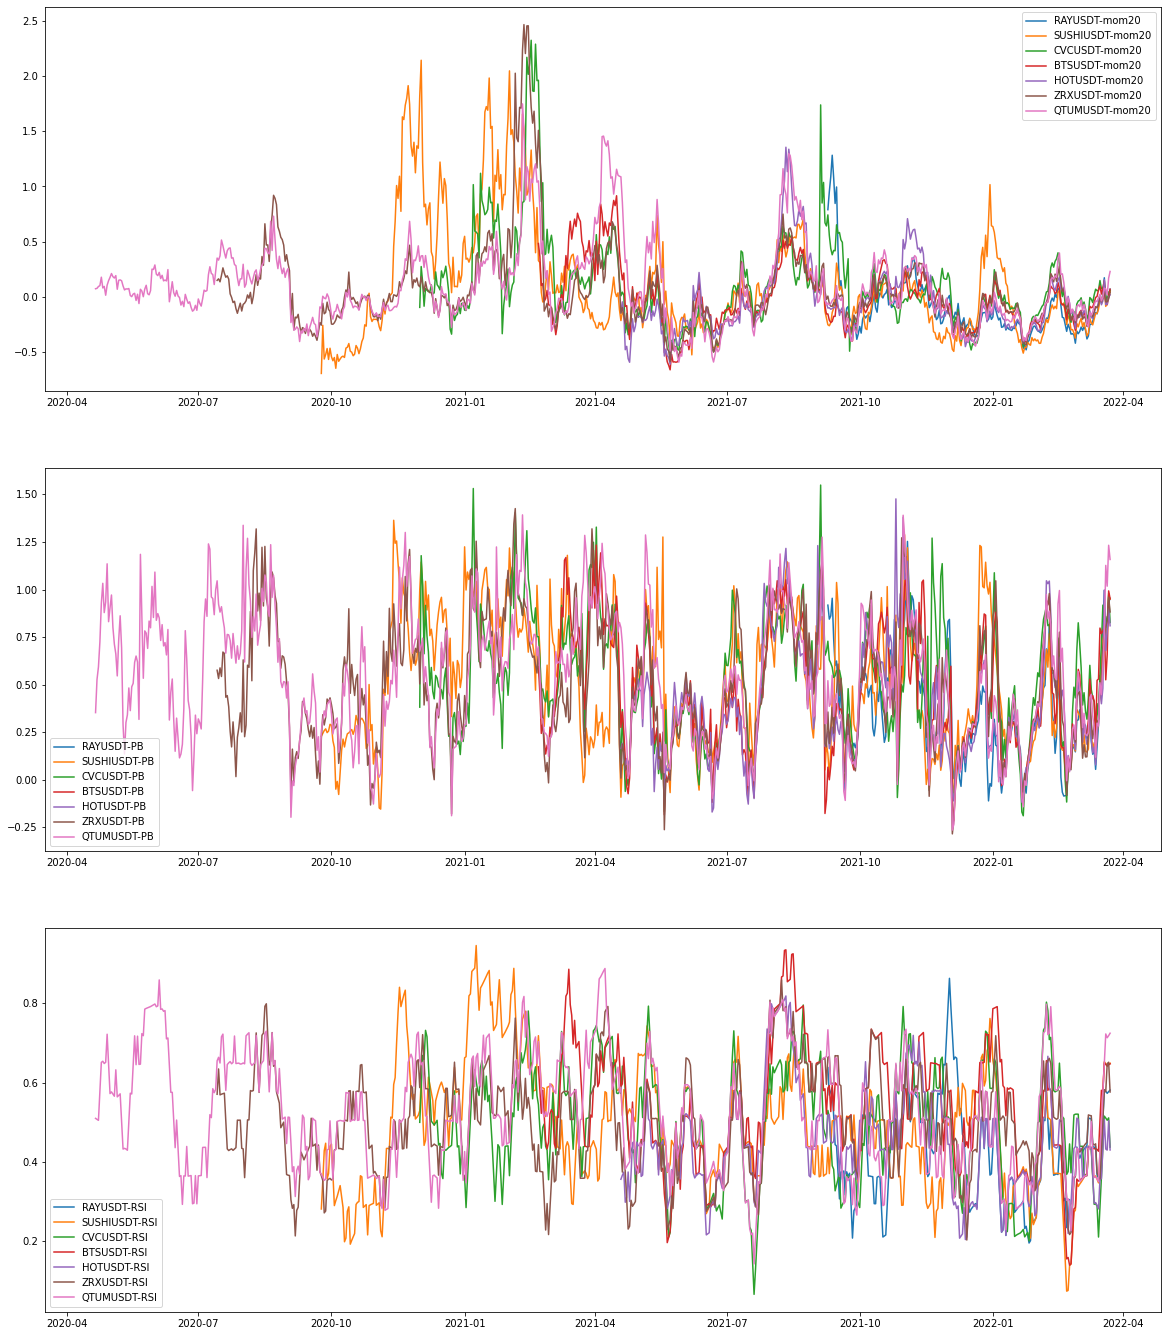

In [34]:
plt.figure(figsize=(20, 24))
plt.subplot(3, 1, 1)
for ticker in list(samples.keys())[:7]:
    plt.plot(samples[ticker].index, samples[ticker].mom20, label=f"{ticker}-mom20")
plt.legend(loc='best')

plt.subplot(3, 1, 2)
for ticker in list(samples.keys())[:7]:
    plt.plot(samples[ticker].index, samples[ticker].percentB, label=f"{ticker}-PB")
plt.legend(loc='best')

plt.subplot(3, 1, 3)
for ticker in list(samples.keys())[:7]:
    plt.plot(samples[ticker].index, samples[ticker].RSI, label=f"{ticker}-RSI")
plt.legend(loc='best')

plt.show()